Implementação de distribuição hipergeométrica

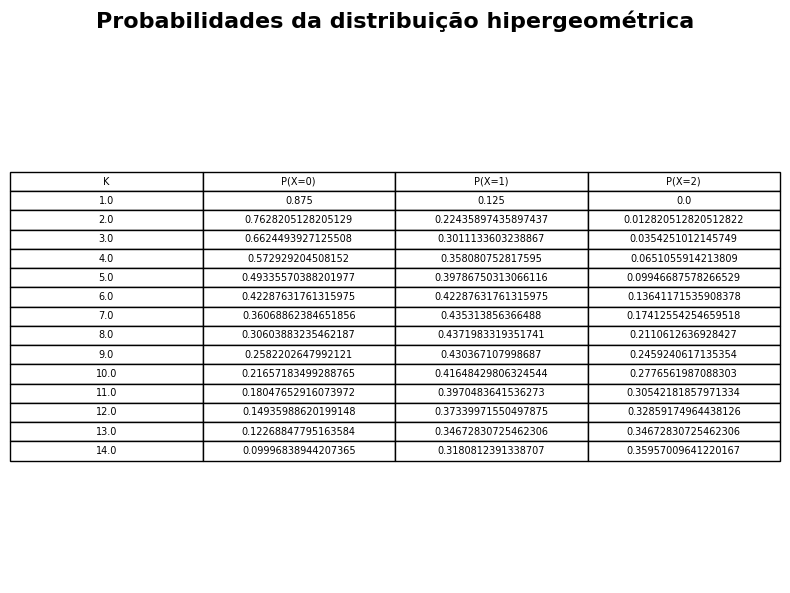

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import hypergeom
import pandas as pd

'''
Os parâmetros são usados como uma aplicação da distribuição hipergeométrica para o planejamento de um baralho de Yu-Gi-Oh! TCG.
O presente código foi feito com auxílio de Inteligência Artificial (IA), que cumpriu o papel de criar um algoritmo base para gerar uma tabela com dados obtidos pela equação da distribuição hipergeométrica.

O código foi revisado pelos autores, com uma curadoria humana, e usado com responsabilidade.
'''

# Parâmetros
N = 40 # Tamanho total da população
n = 5   # Número de cartas puxadas pelo jogador
x_values = [0, 1, 2]  # Valores de x para comparação
K_values = list(range(1, 15))  # Valores diferentes de K (sucessos)

# Dicionário para fazer pares entre os valores
prob_dict = {x: [] for x in x_values}

# Cálculo da probabilidade usando a distribuição hipergeométrica, com parâmetros x, N, K e n.
for K in K_values:
    for x in x_values:
        prob = hypergeom.pmf(x, N, K, n)
        prob_dict[x].append(prob)

# Criação da tabela de valores
data = {'K': K_values}
for x in x_values:
    data[f'P(X={x})'] = prob_dict[x]

df = pd.DataFrame(data)

# Exibir Figura com a tabela
fig, ax = plt.subplots(figsize=(8, 6))  # Set the figure size
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns,fontsize = 16, cellLoc='center', loc='center')

plt.suptitle('Probabilidades da distribuição hipergeométrica', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

Gráfico de hastes para um conjunto de Ks

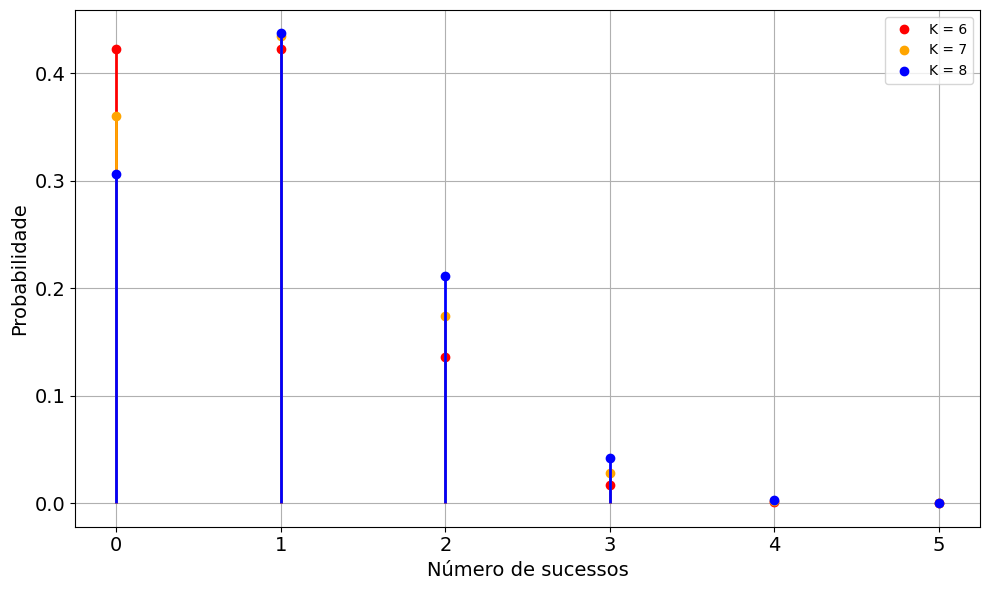

In [6]:
# Parâmetros fixos
N = 40  # tamanho do baralho
n = 5   # tamanho da mão (amostra)
Ks = [6, 7, 8]  # diferentes quantidades de cartas de sucesso no baralho

# Valores de x (número de sucessos possíveis na mão)
x = np.arange(0, n+1)

# Figura
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)

# Cores para cada pilar do gráfico
colors = ['red', 'orange','blue', 'green', 'pink']

# Loop para plotar várias distribuições
for K, color in zip(Ks, colors):
    rv = hypergeom(N, K, n)
    pmf = rv.pmf(x)
    ax.plot(x, pmf, 'o', color=color, label=f'K = {K}')
    ax.vlines(x, 0, pmf, lw=2, color=color)

# Configurações do gráfico de hastes
ax.set_xlabel('Número de sucessos', fontsize = 14)
ax.set_ylabel('Probabilidade', fontsize = 14)
ax.set_title('')
plt.tick_params(axis = 'x', labelsize = 14)
plt.tick_params(axis = 'y', labelsize = 14)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()